# Projeto: Arquitetura de Dados com Apache Spark

### 1. Descrição do Cenário e Fonte de Dados

**Cenário: E-commerce**
O cenário simula o banco de dados relacional de um e-commerce de produtos eletrônicos. O modelo é composto por 5 tabelas que representam o fluxo de vendas: os **Clientes** que realizam compras, os **Produtos** disponíveis (agrupados por **Categorias**), o registro das **Vendas** (cabeçalho do pedido) e os **Itens da Venda** (detalhamento do carrinho). O objetivo é garantir a integridade dessas operações utilizando transações ACID fornecidas pelo Delta Lake / Apache Iceberg.

**Fonte de Dados:**
Para garantir que o ambiente seja 100% reprodutível, a fonte de dados será gerada programaticamente em *DataFrames* dentro do próprio notebook, simulando a ingestão inicial de um sistema transacional (OLTP).

### 2. Modelo de Entidade-Relacionamento (ER)

Abaixo apresentamos o modelo das 5 tabelas que compõem o ecossistema de vendas:

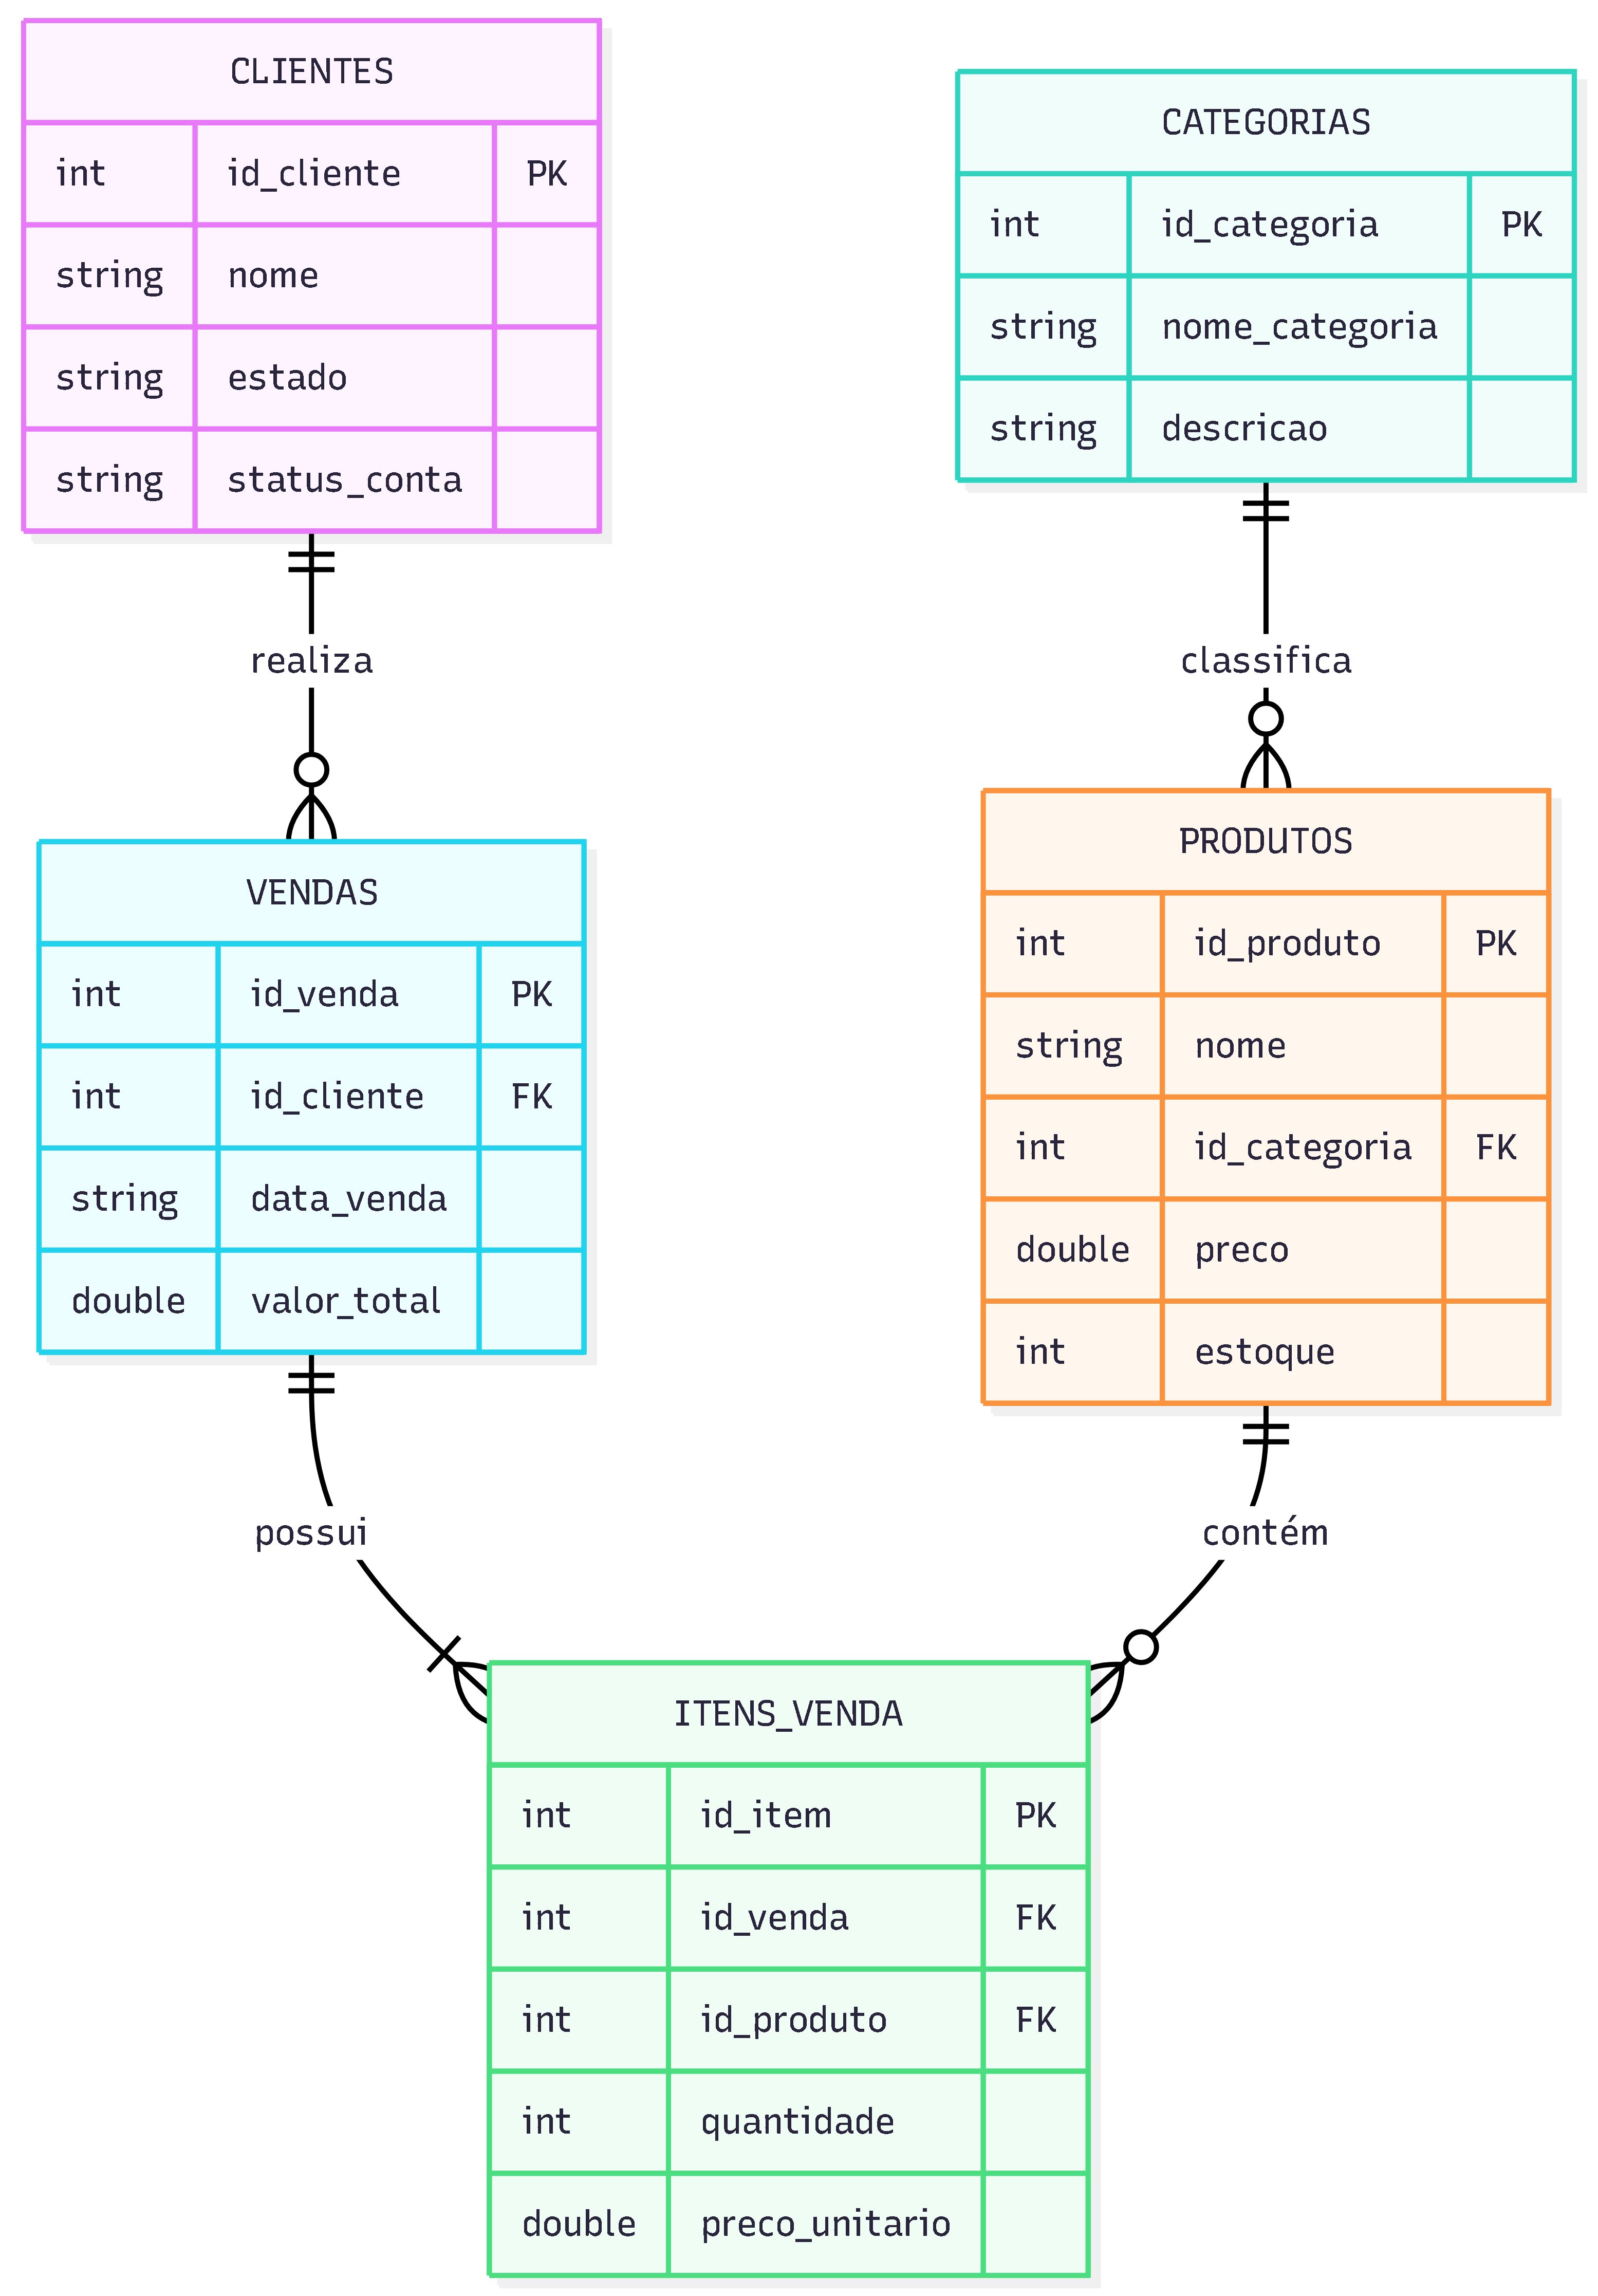

### 3. Códigos DDL (Data Definition Language)

Abaixo estão os códigos de criação (DDL) das 5 tabelas:

```sql
DROP TABLE IF EXISTS itens_venda;
DROP TABLE IF EXISTS vendas;
DROP TABLE IF EXISTS produtos;
DROP TABLE IF EXISTS clientes;
DROP TABLE IF EXISTS categorias;

CREATE TABLE produtos (
    id_produto INT,
    nome STRING,
    id_categoria INT,
    preco DOUBLE,
    estoque INT
) USING delta;

CREATE TABLE categorias (
    id_categoria INT,
    nome_categoria STRING,
    descricao STRING
) USING delta;

CREATE TABLE clientes (
    id_cliente INT,
    nome STRING,
    estado STRING,
    status_conta STRING
) USING delta;

CREATE TABLE vendas (
    id_venda INT,
    id_cliente INT,
    data_venda STRING,
    valor_total DOUBLE
) USING delta;

CREATE TABLE itens_venda (
    id_item INT,
    id_venda INT,
    id_produto INT,
    quantidade INT,
    preco_unitario DOUBLE
) USING delta;

### 4. Configuração do Motor Spark e Delta Lake
Nesta etapa inicial, importamos as bibliotecas necessárias e configuramos a `SparkSession` para reconhecer as extensões do Delta Lake. Também definimos o diretório local onde os arquivos Parquet e os logs de transação serão salvos.

In [1]:
import os
import pyspark
from delta import configure_spark_with_delta_pip

warehouse_path = os.path.abspath("warehouse_delta_lake")

# 1. Configuração da Sessão Spark para usar o Delta Lake
builder = pyspark.sql.SparkSession.builder.appName("Projeto_Arquitetura_Dados_Delta") \
    .config("spark.sql.warehouse.dir", warehouse_path) \
    .config("spark.sql.extensions", "io.delta.sql.DeltaSparkSessionExtension") \
    .config("spark.sql.catalog.spark_catalog", "org.apache.spark.sql.delta.catalog.DeltaCatalog")

# Inicia a sessão
spark = configure_spark_with_delta_pip(builder).getOrCreate()

print(f" Spark iniciado! Os dados do Delta Lake serão salvos na pasta: {warehouse_path}")

your 131072x1 screen size is bogus. expect trouble
26/04/28 03:05:35 WARN Utils: Your hostname, DESKTOP-C71TG2N resolves to a loopback address: 127.0.1.1; using 172.22.160.68 instead (on interface eth0)
26/04/28 03:05:35 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address


:: loading settings :: url = jar:file:/home/ian/trabalho_arquitetura_dados/.venv/lib/python3.12/site-packages/pyspark/jars/ivy-2.5.1.jar!/org/apache/ivy/core/settings/ivysettings.xml


Ivy Default Cache set to: /home/ian/.ivy2/cache
The jars for the packages stored in: /home/ian/.ivy2/jars
io.delta#delta-spark_2.12 added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-8fa3eeff-9b00-4178-8f0b-9d2753188a3c;1.0
	confs: [default]
	found io.delta#delta-spark_2.12;3.1.0 in central
	found io.delta#delta-storage;3.1.0 in central
	found org.antlr#antlr4-runtime;4.9.3 in central
:: resolution report :: resolve 369ms :: artifacts dl 12ms
	:: modules in use:
	io.delta#delta-spark_2.12;3.1.0 from central in [default]
	io.delta#delta-storage;3.1.0 from central in [default]
	org.antlr#antlr4-runtime;4.9.3 from central in [default]
	---------------------------------------------------------------------
	|                  |            modules            ||   artifacts   |
	|       conf       | number| search|dwnlded|evicted|| number|dwnlded|
	---------------------------------------------------------------------
	|      default     |   3   |   0   |  

 Spark iniciado! Os dados do Delta Lake serão salvos na pasta: /home/ian/trabalho_arquitetura_dados/warehouse_delta_lake


### 5. Reset do Ambiente de Testes (Limpeza)
Para garantir que o laboratório possa ser executado múltiplas vezes sem erros de duplicação, utilizamos comandos `DROP TABLE IF EXISTS` para limpar qualquer estado anterior do banco de dados.

In [2]:
import shutil
import os

# 1. Limpeza (Evita erros caso você rode a célula mais de uma vez)
spark.sql("DROP TABLE IF EXISTS itens_venda")
spark.sql("DROP TABLE IF EXISTS vendas")
spark.sql("DROP TABLE IF EXISTS produtos")
spark.sql("DROP TABLE IF EXISTS clientes")
spark.sql("DROP TABLE IF EXISTS categorias")

# 2. Limpeza FÍSICA: Apaga a pasta do warehouse para evitar o erro de 'Location not empty'
if os.path.exists(warehouse_path):
    shutil.rmtree(warehouse_path)
    print(f" Pasta física {warehouse_path} removida com sucesso.")

print(" Ambiente totalmente resetado.")

 Pasta física /home/ian/trabalho_arquitetura_dados/warehouse_delta_lake removida com sucesso.
 Ambiente totalmente resetado.


### 6. Definição do Contrato de Dados (DDL)
Abaixo, criamos a estrutura do nosso Data Lake. O uso da cláusula `USING delta` é o que transforma essas tabelas em entidades transacionais, garantindo o *Schema Enforcement* desde o momento da criação.

In [3]:
# 1. Execução dos códigos DDL para criar as tabelas
spark.sql("""
CREATE TABLE produtos (
    id_produto INT,
    nome STRING,
    id_categoria INT,
    preco DOUBLE,
    estoque INT
) USING delta
""")

spark.sql("""
CREATE TABLE categorias (
    id_categoria INT,
    nome_categoria STRING,
    descricao STRING
) USING delta
""")

spark.sql("""
CREATE TABLE clientes (
    id_cliente INT,
    nome STRING,
    estado STRING,
    status_conta STRING
) USING delta
""")

spark.sql("""
CREATE TABLE vendas (
    id_venda INT,
    id_cliente INT,
    data_venda STRING,
    valor_total DOUBLE
) USING delta
""")

spark.sql("""
CREATE TABLE itens_venda (
    id_item INT,
    id_venda INT,
    id_produto INT,
    quantidade INT,
    preco_unitario DOUBLE
) USING delta
""")


print("SUCESSO! Todas as 5 tabelas do seu modelo E-commerce foram criadas")

# Validando o ambiente listando as tabelas recém-criadas
spark.sql("SHOW TABLES").show()

26/04/28 03:05:56 WARN GarbageCollectionMetrics: To enable non-built-in garbage collector(s) List(G1 Concurrent GC), users should configure it(them) to spark.eventLog.gcMetrics.youngGenerationGarbageCollectors or spark.eventLog.gcMetrics.oldGenerationGarbageCollectors
26/04/28 03:05:56 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


SUCESSO! Todas as 5 tabelas do seu modelo E-commerce foram criadas
+---------+-----------+-----------+
|namespace|  tableName|isTemporary|
+---------+-----------+-----------+
|  default| categorias|      false|
|  default|   clientes|      false|
|  default|itens_venda|      false|
|  default|   produtos|      false|
|  default|     vendas|      false|
+---------+-----------+-----------+



### 7. Operações DML (Data Manipulation Language) no Delta Lake

Uma das grandes vantagens do Delta Lake em relação aos "Data Lakes" tradicionais é o suporte total a transações ACID. Isso nos permite realizar operações de manipulação direta nos dados, como se estivéssemos em um banco de dados relacional clássico. 

Abaixo, evidenciamos essas operações na nossa tabela de `produtos`:
* **INSERT:** Adicionando um novo produto ao catálogo.
* **UPDATE:** Atualizando o preço de um produto devido à inflação.
* **DELETE:** Removendo um produto que saiu de linha.

#### 7.0. Estado Inicial da Tabela
Antes de iniciar, verificamos que a tabela de produtos está devidamente criada e vazia.

In [4]:
# === 0. Mostrar Estado Inicial ===
print("--- TABELA ORIGINAL ---")
spark.sql("SELECT * FROM produtos ORDER BY id_produto").show()

--- TABELA ORIGINAL ---


+----------+----+------------+-----+-------+
|id_produto|nome|id_categoria|preco|estoque|
+----------+----+------------+-----+-------+
+----------+----+------------+-----+-------+



#### 7.1. Operação de INSERT
Adicionamos múltiplos produtos novos ao catálogo em uma única transação atômica.

In [5]:
spark.sql("""
    INSERT INTO produtos VALUES
    (104, 'Smartwatch Pro', 1, 1500.00, 50),
    (105, 'Teclado Mecânico RGB', 2, 450.00, 120),
    (106, 'Monitor Ultrawide 34"', 2, 2800.00, 30)
""")

print("--- DEPOIS DO INSERT (3 Novos produtos adicionados) ---")
spark.sql("SELECT * FROM produtos ORDER BY id_produto").show()

--- DEPOIS DO INSERT (3 Novos produtos adicionados) ---


+----------+--------------------+------------+------+-------+
|id_produto|                nome|id_categoria| preco|estoque|
+----------+--------------------+------------+------+-------+
|       104|      Smartwatch Pro|           1|1500.0|     50|
|       105|Teclado Mecânico RGB|           2| 450.0|    120|
|       106|Monitor Ultrawide...|           2|2800.0|     30|
+----------+--------------------+------------+------+-------+



#### 7.2. Operação de UPDATE
Realizamos a atualização seletiva de preço e estoque. Neste exemplo, ajustamos o valor do Monitor (ID 106) e reduzimos seu estoque para simular uma venda.

In [6]:
spark.sql("""
    UPDATE produtos
    SET preco = 6200.00, 
        estoque = estoque - 5
    WHERE id_produto = 106
""")

print("--- DEPOIS DO UPDATE (Monitor 106 atualizado) ---")
spark.sql("SELECT * FROM produtos ORDER BY id_produto").show()

--- DEPOIS DO UPDATE (Monitor 106 atualizado) ---
+----------+--------------------+------------+------+-------+
|id_produto|                nome|id_categoria| preco|estoque|
+----------+--------------------+------------+------+-------+
|       104|      Smartwatch Pro|           1|1500.0|     50|
|       105|Teclado Mecânico RGB|           2| 450.0|    120|
|       106|Monitor Ultrawide...|           2|6200.0|     25|
+----------+--------------------+------------+------+-------+



#### 7.3. Operação de DELETE
Demonstração da remoção física de um registro. Removemos o Teclado (ID 105) do nosso catálogo de produtos.

In [7]:
spark.sql("""
    DELETE FROM produtos
    WHERE id_produto = 105
""")

print("--- DEPOIS DO DELETE (Produto 105 removido) ---")
spark.sql("SELECT * FROM produtos ORDER BY id_produto").show()

--- DEPOIS DO DELETE (Produto 105 removido) ---
+----------+--------------------+------------+------+-------+
|id_produto|                nome|id_categoria| preco|estoque|
+----------+--------------------+------------+------+-------+
|       104|      Smartwatch Pro|           1|1500.0|     50|
|       106|Monitor Ultrawide...|           2|6200.0|     25|
+----------+--------------------+------------+------+-------+



#### 7.4. Operação de MERGE (Upsert)
A operação de `MERGE` permite sincronizar dados de uma origem com o destino em uma única transação:
* **Update:** O Smartwatch (ID 104) será atualizado para a versão V2 e terá seu preço e estoque reajustados.
* **Insert:** O Mouse Sem Fio (ID 107) será inserido pois não existe na tabela de destino.

In [8]:
spark.sql("""
    MERGE INTO produtos destino
    USING (
        SELECT 104 as id_produto, 'Smartwatch Pro V2' as nome, 1 as id_categoria, 1650.00 as preco, 80 as estoque
        UNION ALL
        SELECT 107 as id_produto, 'Mouse Sem Fio', 2 as id_categoria, 180.00 as preco, 200 as estoque
    ) origem
    ON destino.id_produto = origem.id_produto
    
    WHEN MATCHED THEN
        UPDATE SET 
            destino.nome = origem.nome, 
            destino.preco = origem.preco, 
            destino.estoque = origem.estoque
            
    WHEN NOT MATCHED THEN
        INSERT (id_produto, nome, id_categoria, preco, estoque)
        VALUES (origem.id_produto, origem.nome, origem.id_categoria, origem.preco, origem.estoque)
""")

print("--- DEPOIS DO MERGE (Sincronização Final Concluída) ---")
spark.sql("SELECT * FROM produtos ORDER BY id_produto").show()

--- DEPOIS DO MERGE (Sincronização Final Concluída) ---
+----------+--------------------+------------+------+-------+
|id_produto|                nome|id_categoria| preco|estoque|
+----------+--------------------+------------+------+-------+
|       104|   Smartwatch Pro V2|           1|1650.0|     80|
|       106|Monitor Ultrawide...|           2|6200.0|     25|
|       107|       Mouse Sem Fio|           2| 180.0|    200|
+----------+--------------------+------------+------+-------+

